In [1]:
import pandas as pd

In [2]:

results_folder = f'LFR_Graph_Data/Community_Data/louvain/results/mu_0_4'

In [3]:
df = pd.read_csv(f'{results_folder}/all_y_train.csv')

In [3]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

def load_stability_stats(base_path, algorithm, mu_values):
    """
    Carrega os rótulos já classificados pelo K-means (y_train.csv)
    """
    results = []
    
    for mu in mu_values:
        mu_str = str(mu).replace('.', '_')
        mu_dir = f'mu_{mu_str}'
        
        labels_path = Path(base_path) / algorithm / 'results' / mu_dir
        
        if not labels_path.exists():
            print(f"⚠️ Caminho não encontrado: {labels_path}")
            continue
        
        label_files = list(labels_path.glob('*y_train.csv'))
        
        if not label_files:
            print(f"⚠️ Nenhum arquivo y_train.csv encontrado em: {labels_path}")
            continue
        
        print(f"📊 {algorithm.upper()}, μ={mu}: {len(label_files)} arquivos")
        
        unstable_ratios = []
        total_nodes = 0
        total_unstable = 0
        
        for file in label_files:
            try:
                df = pd.read_csv(file)
                
                # Identifica coluna de rótulos
                label_col = [col for col in df.columns if 'label' in col.lower() or 'y' in col.lower() or 'Stability' in col]
                if not label_col:
                    label_col = df.columns[0]
                else:
                    label_col = label_col[0]
                
                labels = df[label_col].values
                n_nodes = len(labels)
                n_unstable = np.sum(labels == 1)
                
                unstable_ratios.append(n_unstable / n_nodes)
                total_nodes += n_nodes
                total_unstable += n_unstable
                
            except Exception as e:
                print(f"  ❌ Erro: {file.name} - {e}")
                continue
        
        if unstable_ratios:
            stats = {
                'algorithm': f"{algorithm.upper()} (μ={mu})",
                'total_nodes': total_nodes,
                'total_unstable_percent': (total_unstable / total_nodes) * 100,
                'mean_percent': np.mean(unstable_ratios) * 100,
                'median_percent': np.median(unstable_ratios) * 100,
                'std_percent': np.std(unstable_ratios) * 100
            }
            results.append(stats)
    
    return pd.DataFrame(results)


def main():
    base_path = "LFR_Graph_Data/Community_Data"
    algorithms = ['Infomap', 'louvain', 'lpa']
    mu_values = [0.2, 0.3, 0.4]
    
    print("=" * 70)
    print("ANÁLISE DE ESTABILIDADE - NÓS INSTÁVEIS")
    print("=" * 70)
    
    all_results = []
    
    for algorithm in algorithms:
        print(f"\n▶️ {algorithm.upper()}")
        df = load_stability_stats(base_path, algorithm, mu_values)
        if not df.empty:
            all_results.append(df)
    
    if not all_results:
        print("\n❌ Nenhum dado encontrado.")
        return
    
    master_df = pd.concat(all_results, ignore_index=True)
    
    # Tabela final
    print("\n" + "=" * 70)
    print("RESULTADOS - PROPORÇÃO DE NÓS INSTÁVEIS")
    print("=" * 70)
    
    result_table = master_df[['algorithm', 'total_unstable_percent', 
                              'mean_percent', 'median_percent', 
                              'std_percent', 'total_nodes']].copy()
    
    result_table.columns = ['Algoritmo (μ)', '% Instável', 'Média (%)', 
                            'Mediana (%)', 'Desv.Pad (%)', 'Total Nós']
    
    # Formatação
    for col in ['% Instável', 'Média (%)', 'Mediana (%)', 'Desv.Pad (%)']:
        result_table[col] = result_table[col].map('{:.1f}'.format)
    result_table['Total Nós'] = result_table['Total Nós'].map('{:,}'.format)
    
    print(result_table.to_string(index=False))
    
    # Salva
    master_df.to_csv("stability_stats_summary.csv", index=False)
    print("\n💾 Salvo: stability_stats_summary.csv")
    
    return master_df


if __name__ == "__main__":
    df = main()

ANÁLISE DE ESTABILIDADE - NÓS INSTÁVEIS

▶️ INFOMAP
⚠️ Nenhum arquivo y_train.csv encontrado em: LFR_Graph_Data/Community_Data/Infomap/results/mu_0_2
⚠️ Nenhum arquivo y_train.csv encontrado em: LFR_Graph_Data/Community_Data/Infomap/results/mu_0_3
⚠️ Caminho não encontrado: LFR_Graph_Data/Community_Data/Infomap/results/mu_0_4

▶️ LOUVAIN
📊 LOUVAIN, μ=0.2: 121 arquivos
📊 LOUVAIN, μ=0.3: 121 arquivos
📊 LOUVAIN, μ=0.4: 121 arquivos

▶️ LPA
📊 LPA, μ=0.2: 121 arquivos
📊 LPA, μ=0.3: 121 arquivos
⚠️ Caminho não encontrado: LFR_Graph_Data/Community_Data/lpa/results/mu_0_4

RESULTADOS - PROPORÇÃO DE NÓS INSTÁVEIS
  Algoritmo (μ) % Instável Média (%) Mediana (%) Desv.Pad (%) Total Nós
LOUVAIN (μ=0.2)       42.9      43.0        42.9          0.4    70,510
LOUVAIN (μ=0.3)       42.9      42.9        42.9          0.7    96,522
LOUVAIN (μ=0.4)       42.9      42.9        42.9          0.1    98,500
    LPA (μ=0.2)       42.9      42.9        42.9          0.3   152,040
    LPA (μ=0.3)       42.9  

DIAGNÓSTICO DA MATRIZ DE CO-ASSOCIAÇÃO
Arquivo: /home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data/Infomap/rCoassociation/graph_01_mu_0_4_coassociation.npy
----------------------------------------------------------------------

📊 Informações básicas:
   Shape: (1000, 1000)
   Tipo: float32
   Memória: 3.81 MB

📈 Estatísticas dos valores:
   Valores únicos: [0. 1.]
   Número de valores únicos: 2
   Mínimo: 0.000000
   Máximo: 1.000000
   Média: 0.032138
   Mediana: 0.000000

🔍 Diagnóstico:
   ⚠️ PROBLEMA DETECTADO: Matriz contém APENAS 0 e 1
      → Todas as execuções produziram partições IDÊNTICAS
      → NÃO há variabilidade entre as execuções
      → Entropia será ZERO para todos os nós
      → Proporção de pares na mesma comunidade: 0.032
      → Matriz é simétrica: True

📊 Entropia por nó (E_i):
   Média: 0.000000
   Mediana: 0.000000
   Desvio padrão: 0.000000
   Mínimo: 0.000000
   Máximo: 0.000000
   Proporção de nós com entro

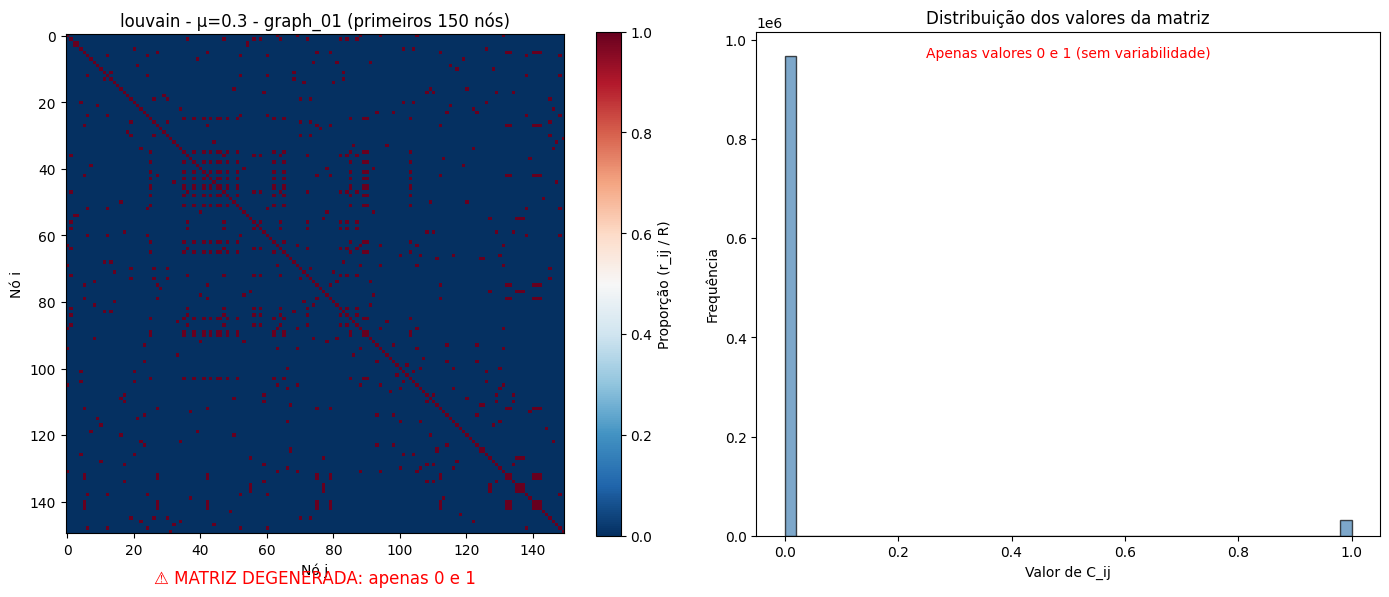


💾 Entropias salvas em: louvain_mu_03_entropies_calculated.csv


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

def diagnose_coassociation_matrix(file_path):
    """
    Diagnostica uma matriz de co-associação específica
    
    Parâmetros:
    - file_path: caminho completo para o arquivo .npy
    """
    
    print("=" * 70)
    print(f"DIAGNÓSTICO DA MATRIZ DE CO-ASSOCIAÇÃO")
    print("=" * 70)
    print(f"Arquivo: {file_path}")
    print("-" * 70)
    
    # Carrega matriz
    C = np.load(file_path)
    print(f"\n📊 Informações básicas:")
    print(f"   Shape: {C.shape}")
    print(f"   Tipo: {C.dtype}")
    print(f"   Memória: {C.nbytes / 1024 / 1024:.2f} MB")
    
    # Estatísticas dos valores
    unique_values = np.unique(C)
    print(f"\n📈 Estatísticas dos valores:")
    print(f"   Valores únicos: {unique_values[:10]}{'...' if len(unique_values) > 10 else ''}")
    print(f"   Número de valores únicos: {len(unique_values)}")
    print(f"   Mínimo: {C.min():.6f}")
    print(f"   Máximo: {C.max():.6f}")
    print(f"   Média: {C.mean():.6f}")
    print(f"   Mediana: {np.median(C):.6f}")
    
    # Verifica caso degenerado (apenas 0 e 1)
    is_binary = np.all(np.isin(C, [0, 1]))
    print(f"\n🔍 Diagnóstico:")
    
    if is_binary:
        print("   ⚠️ PROBLEMA DETECTADO: Matriz contém APENAS 0 e 1")
        print("      → Todas as execuções produziram partições IDÊNTICAS")
        print("      → NÃO há variabilidade entre as execuções")
        print("      → Entropia será ZERO para todos os nós")
        
        proportion_same = C.mean()
        print(f"      → Proporção de pares na mesma comunidade: {proportion_same:.3f}")
        
        # Verifica simetria
        is_symmetric = np.allclose(C, C.T, atol=1e-10)
        print(f"      → Matriz é simétrica: {is_symmetric}")
        
    else:
        # Verifica se há valores fracionários
        fractional = unique_values[(unique_values > 0) & (unique_values < 1)]
        print(f"   ✅ Comportamento NORMAL: Matriz contém valores fracionários")
        print(f"      → Valores entre 0 e 1: {len(fractional)} valores únicos")
        print(f"      → Exemplos: {fractional[:5]}")
        print("      → Há variabilidade entre as execuções")
        print("      → Entropias serão NÃO-zero para alguns nós")
    
    # Calcula entropia por nó
    entropies = compute_entropy_from_coassociation(C)
    
    print(f"\n📊 Entropia por nó (E_i):")
    print(f"   Média: {np.mean(entropies):.6f}")
    print(f"   Mediana: {np.median(entropies):.6f}")
    print(f"   Desvio padrão: {np.std(entropies):.6f}")
    print(f"   Mínimo: {np.min(entropies):.6f}")
    print(f"   Máximo: {np.max(entropies):.6f}")
    print(f"   Proporção de nós com entropia = 0: {np.mean(entropies == 0):.2%}")
    print(f"   Proporção de nós com entropia > 0: {np.mean(entropies > 0):.2%}")
    
    # Análise da distribuição
    print(f"\n📊 Distribuição das entropias (percentis):")
    for p in [10, 25, 50, 75, 90]:
        print(f"   {p}º percentil: {np.percentile(entropies, p):.6f}")
    
    return C, entropies


def compute_entropy_from_coassociation(C):
    """
    Calcula entropia por nó a partir da matriz de co-associação
    
    Fórmula: E_i = (1/N) * sum_j p_ij
    onde p_ij = C_ij * log2(C_ij) se C_ij > 0, senão 0
    """
    N = C.shape[0]
    entropies = np.zeros(N)
    
    for i in range(N):
        # Evita calcular log(0) e otimiza para valores 0 e 1
        row = C[i]
        # Apenas valores entre 0 e 1 (exclusive) contribuem
        mask = (row > 0) & (row < 1)
        if np.any(mask):
            p_ij = row[mask] * np.log2(row[mask])
            entropies[i] = np.sum(p_ij) / N
        # Se todos são 0 ou 1, entropia permanece 0
    
    return entropies


def plot_coassociation_heatmap(C, title=None, max_nodes=200):
    """
    Plota heatmap da matriz de co-associação
    """
    if title is None:
        title = "Matriz de Co-associação"
    
    # Limita o tamanho para visualização
    n_plot = min(max_nodes, C.shape[0])
    C_subset = C[:n_plot, :n_plot]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Heatmap completo
    im1 = axes[0].imshow(C_subset, cmap='RdBu_r', interpolation='nearest', vmin=0, vmax=1)
    axes[0].set_title(f"{title} (primeiros {n_plot} nós)", fontsize=12)
    axes[0].set_xlabel("Nó j")
    axes[0].set_ylabel("Nó i")
    plt.colorbar(im1, ax=axes[0], label="Proporção (r_ij / R)")
    
    # Histograma dos valores
    values = C.flatten()
    # Remove valores 0 e 1 para melhor visualização (se existirem)
    fractional_values = values[(values > 0) & (values < 1)]
    
    axes[1].hist(values, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1].set_title("Distribuição dos valores da matriz", fontsize=12)
    axes[1].set_xlabel("Valor de C_ij")
    axes[1].set_ylabel("Frequência")
    
    # Adiciona anotação sobre degeneração
    if np.all(np.isin(C, [0, 1])):
        axes[0].text(0.5, -0.1, "⚠️ MATRIZ DEGENERADA: apenas 0 e 1", 
                    transform=axes[0].transAxes, ha='center', fontsize=12, color='red')
        axes[1].text(0.5, 0.95, "Apenas valores 0 e 1 (sem variabilidade)", 
                    transform=axes[1].transAxes, ha='center', fontsize=10, color='red')
    
    plt.tight_layout()
    return fig


def compare_coassociation_matrices(file_paths, labels=None):
    """
    Compara múltiplas matrizes de co-associação
    """
    print("\n" + "=" * 70)
    print("COMPARAÇÃO ENTRE MATRIZES")
    print("=" * 70)
    
    results = []
    
    for i, file_path in enumerate(file_paths):
        C = np.load(file_path)
        entropies = compute_entropy_from_coassociation(C)
        
        label = labels[i] if labels else Path(file_path).name
        
        results.append({
            'arquivo': label,
            'shape': C.shape,
            'valores_unicos': len(np.unique(C)),
            'apenas_0_1': np.all(np.isin(C, [0, 1])),
            'entropia_media': np.mean(entropies),
            'entropia_max': np.max(entropies),
            'prop_zero_entropy': np.mean(entropies == 0),
            'prop_pos_entropy': np.mean(entropies > 0)
        })
    
    df = pd.DataFrame(results)
    print(df.to_string(index=False))
    
    return df


# ============================================================================
# EXECUÇÃO PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    
    # Arquivo específico que você forneceu
    file_path = "/home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data/Infomap/rCoassociation/graph_01_mu_0_4_coassociation.npy"
    
    # Verifica se o arquivo existe
    if Path(file_path).exists():
        # Diagnóstico completo
        C, entropies = diagnose_coassociation_matrix(file_path)
        
        # Visualização
        fig = plot_coassociation_heatmap(C, title=f"louvain - μ=0.3 - graph_01", max_nodes=150)
        plt.savefig("infomap_mu_03_coassociation_heatmap.png", dpi=150, bbox_inches='tight')
        plt.show()
        
        # Salva entropias calculadas
        entropy_df = pd.DataFrame({
            'node': [f"node_{i}" for i in range(len(entropies))],
            'entropy': entropies
        })
        entropy_df.to_csv("louvain_mu_03_entropies_calculated.csv", index=False)
        print(f"\n💾 Entropias salvas em: louvain_mu_03_entropies_calculated.csv")
        
    else:
        print(f"❌ Arquivo não encontrado: {file_path}")
        
        # Tenta encontrar arquivos alternativos
        base_dir = Path("/LFR_Graph_Data/Community_Data/louvain/rCoassociation")
        
        if base_dir.exists():
            print(f"\n📂 Procurando arquivos em: {base_dir}")
            files = list(base_dir.glob("*.npy"))
            if files:
                print(f"   Encontrados {len(files)} arquivos:")
                for f in files[:5]:
                    print(f"     - {f.name}")
            else:
                print("   Nenhum arquivo .npy encontrado")

🔍 CARREGANDO RESULTADOS DOS ARQUIVOS PKL
✅ LOUVAIN - mu_0_2: 120 grafos, 35255 nós
✅ LOUVAIN - mu_0_3: 120 grafos, 32174 nós
✅ LOUVAIN - mu_0_4: 120 grafos, 49250 nós
✅ LPA - mu_0_2: 120 grafos, 50680 nós
✅ LPA - mu_0_3: 120 grafos, 105216 nós
⚠️ PKL não encontrado: /home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data/lpa/results/mu_0_4/all_graphs_results.pkl
⚠️ PKL não encontrado: /home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data/infomap/results/mu_0_2/all_graphs_results.pkl
⚠️ PKL não encontrado: /home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data/infomap/results/mu_0_3/all_graphs_results.pkl
⚠️ PKL não encontrado: /home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data/infomap/results/mu_0_4/all_graphs_results.pkl

📊 GERANDO VISUALIZAÇÕES

1. Gráfico de barras comparativo...


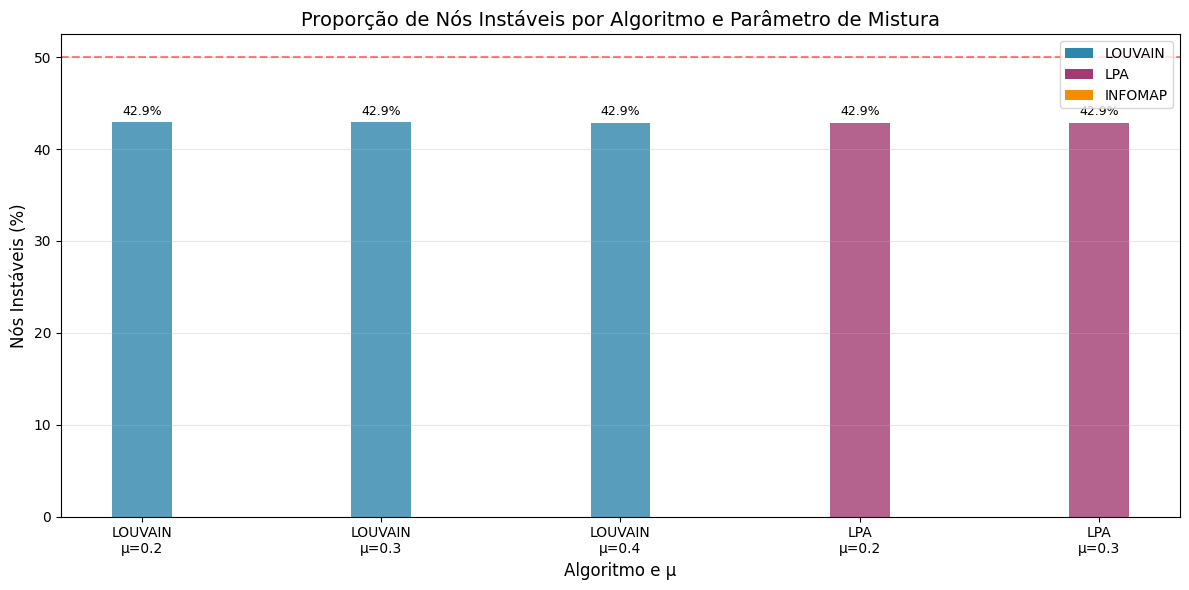


2. Boxplots...


/tmp/ipykernel_1034/3173172875.py:190: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


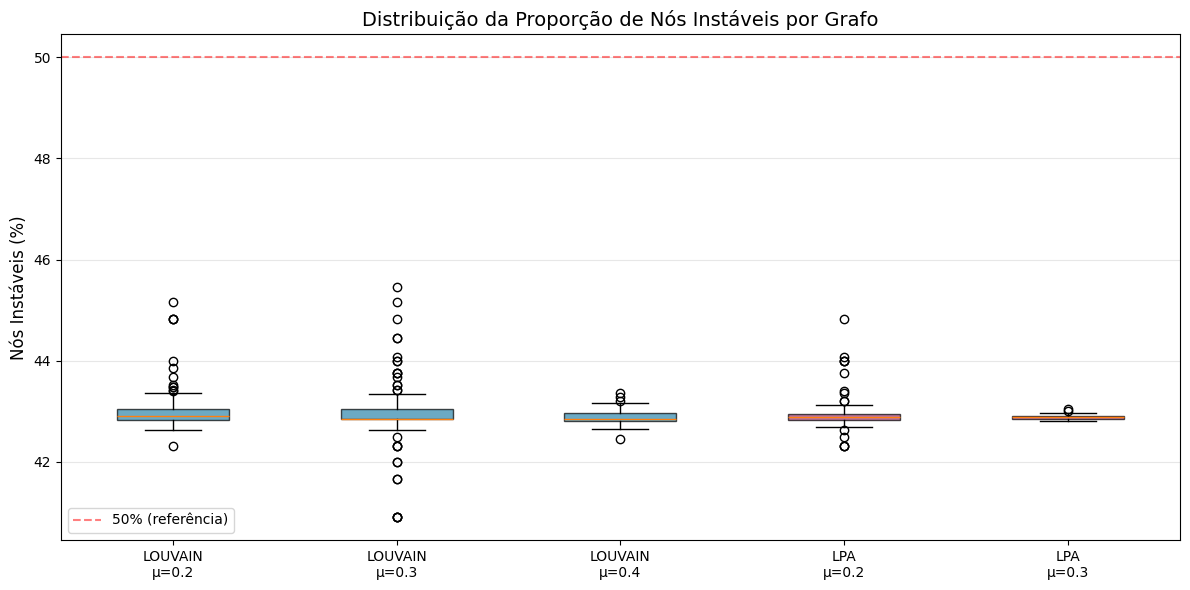


3. Heatmap...


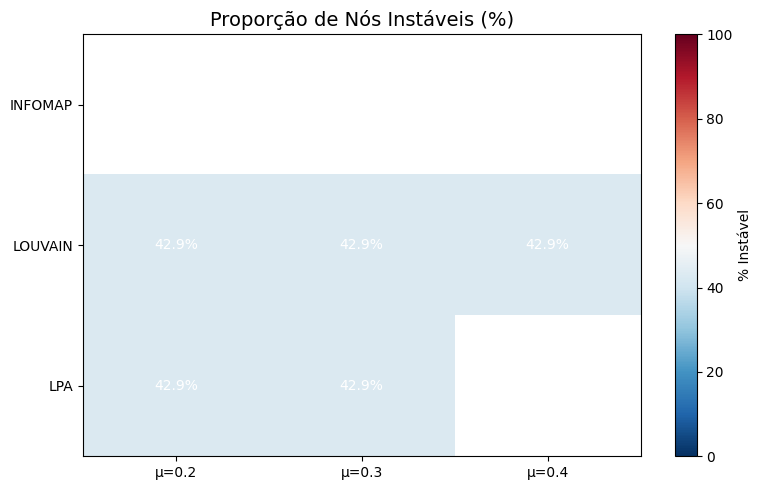


4. Evolução com μ...


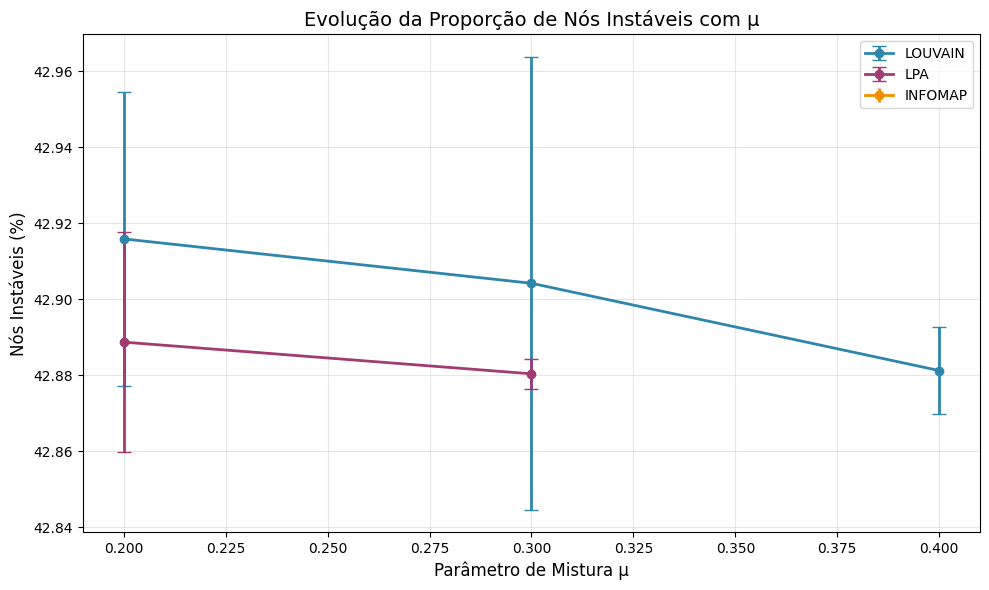


5. Distribuição por grafo...


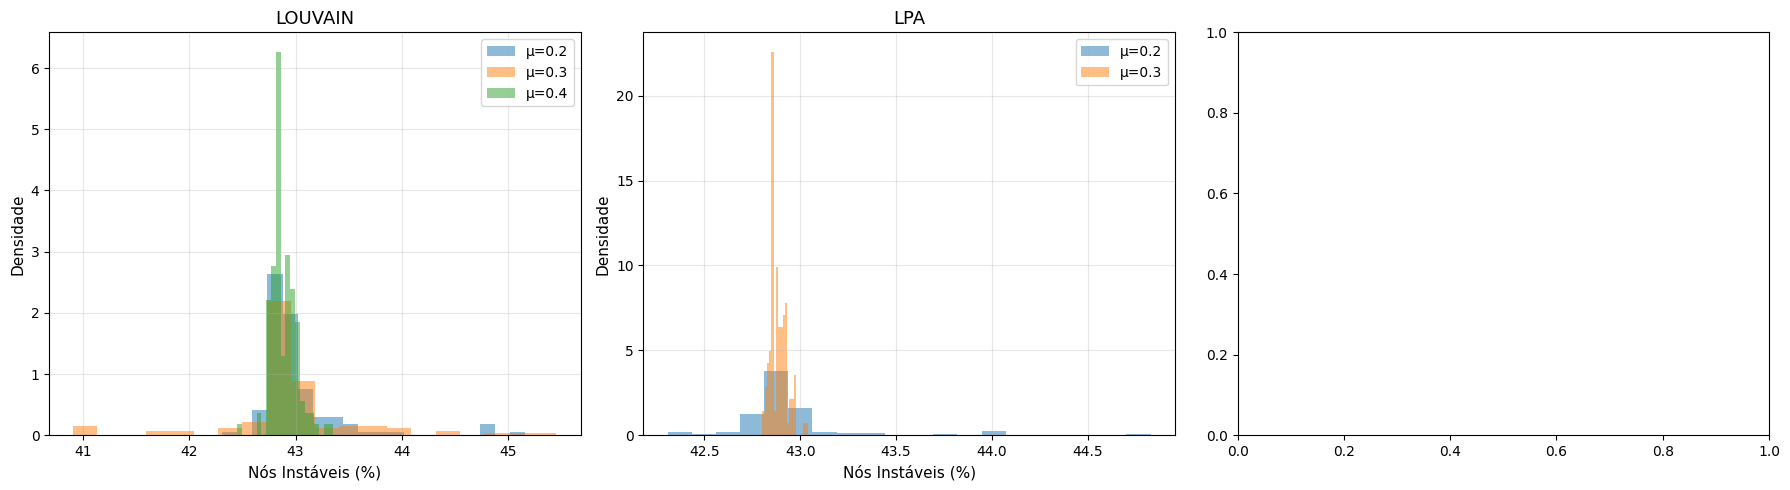


6. Violin plot...


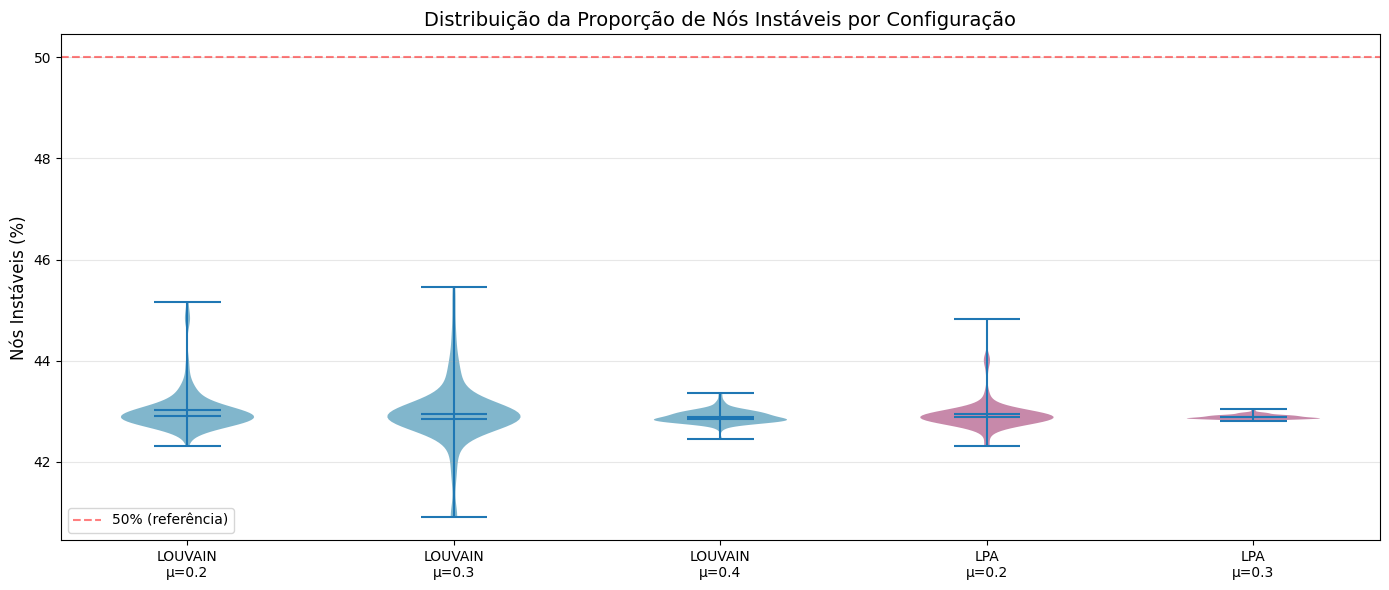


💾 Dados resumo salvos em: Resultados/stability_plots/stability_summary.csv

📊 TABELA RESUMO
Algoritmo   μ  Nº Grafos  Total Nós  Nós Estáveis  Nós Instáveis  % Instável
  LOUVAIN 0.2        120      35255         20125          15130   42.915898
  LOUVAIN 0.3        120      32174         18370          13804   42.904208
  LOUVAIN 0.4        120      49250         28131          21119   42.881218
      LPA 0.2        120      50680         28944          21736   42.888713
      LPA 0.3        120     105216         60099          45117   42.880360

✅ ANÁLISE CONCLUÍDA!
📁 Gráficos salvos em: Resultados/stability_plots


In [5]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

# ============================================
# CONFIGURAÇÃO
# ============================================

BASE_PATH = "/home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data"

algorithms = ['louvain', 'lpa', 'infomap']
mu_values = [0.2, 0.3, 0.4]

# Cores para cada algoritmo
COLORS = {
    'louvain': '#2E86AB',
    'lpa': '#A23B72',
    'infomap': '#F18F01'
}

# ============================================
# FUNÇÃO PARA CARREGAR TODOS OS PKL
# ============================================

def load_all_pkl_results(base_path, algorithms, mu_values):
    """
    Carrega todos os arquivos .pkl e extrai informações de treinamento.
    """
    all_data = {}
    
    for algorithm in algorithms:
        all_data[algorithm] = {}
        for mu in mu_values:
            mu_str = str(mu).replace('.', '_')
            mu_label = f"mu_{mu_str}"
            
            pkl_path = Path(base_path) / algorithm / 'results' / mu_label / 'all_graphs_results.pkl'
            
            if not pkl_path.exists():
                print(f"⚠️ PKL não encontrado: {pkl_path}")
                continue
            
            try:
                with open(pkl_path, 'rb') as f:
                    data = pickle.load(f)
                
                # Extrai informações por grafo
                per_graph = []
                total_stable = 0
                total_unstable = 0
                
                for graph_name, graph_data in data.items():
                    # Tenta obter distribuição das classes
                    n_stable = 0
                    n_unstable = 0
                    
                    if 'train_test_info' in graph_data:
                        dist = graph_data['train_test_info'].get('y_train_distribution', {})
                        n_stable = dist.get(0, 0)
                        n_unstable = dist.get(1, 0)
                        
                        # Fallback: tenta obter de 'Stable Nodes' e 'Unstable Nodes'
                        if n_stable == 0 and n_unstable == 0:
                            n_stable = graph_data.get('Stable Nodes', 0)
                            n_unstable = graph_data.get('Unstable Nodes', 0)
                    
                    total = n_stable + n_unstable
                    total_stable += n_stable
                    total_unstable += n_unstable
                    
                    per_graph.append({
                        'graph': graph_name,
                        'n_stable': n_stable,
                        'n_unstable': n_unstable,
                        'total': total,
                        'unstable_ratio': n_unstable / total if total > 0 else 0
                    })
                
                all_data[algorithm][mu] = {
                    'n_graphs': len(data),
                    'total_stable': total_stable,
                    'total_unstable': total_unstable,
                    'total_nodes': total_stable + total_unstable,
                    'unstable_percent': (total_unstable / (total_stable + total_unstable)) * 100 if (total_stable + total_unstable) > 0 else 0,
                    'per_graph': per_graph
                }
                
                print(f"✅ {algorithm.upper()} - {mu_label}: {len(data)} grafos, {total_stable + total_unstable} nós")
                
            except Exception as e:
                print(f"❌ Erro em {pkl_path}: {e}")
    
    return all_data

# ============================================
# VISUALIZAÇÃO 1: GRÁFICO DE BARRAS COMPARATIVO
# ============================================

def plot_stability_comparison(all_data, output_dir="Resultados/stability_plots"):
    """
    Cria gráfico de barras comparando % de nós instáveis por algoritmo e μ.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Prepara dados
    data = []
    for algorithm in all_data:
        for mu, info in all_data[algorithm].items():
            data.append({
                'Algoritmo': algorithm.upper(),
                'μ': mu,
                '% Instável': info['unstable_percent'],
                'Nós Totais': info['total_nodes'],
                'Nº Grafos': info['n_graphs']
            })
    
    df = pd.DataFrame(data)
    
    # Cria figura
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Posições das barras
    x = np.arange(len(df))
    width = 0.25
    
    # Cores para cada algoritmo
    color_map = {alg.upper(): COLORS.get(alg, '#888888') for alg in algorithms}
    colors = [color_map.get(row['Algoritmo'], '#888888') for _, row in df.iterrows()]
    
    # Gráfico de barras
    bars = ax.bar(x, df['% Instável'], width, color=colors, alpha=0.8)
    
    # Configurações
    ax.set_xlabel('Algoritmo e μ', fontsize=12)
    ax.set_ylabel('Nós Instáveis (%)', fontsize=12)
    ax.set_title('Proporção de Nós Instáveis por Algoritmo e Parâmetro de Mistura', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{row['Algoritmo']}\nμ={row['μ']}" for _, row in df.iterrows()], fontsize=10)
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% (referência)')
    
    # Adiciona valores nas barras
    for bar, value in zip(bars, df['% Instável']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{value:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Adiciona legenda
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=alg.upper()) 
                       for alg, color in color_map.items()]
    ax.legend(handles=legend_elements, loc='upper right')
    
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    
    # Salva
    plt.savefig(os.path.join(output_dir, 'stability_comparison_bars.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    return df

# ============================================
# VISUALIZAÇÃO 2: BOXPLOT POR CONFIGURAÇÃO
# ============================================

def plot_stability_boxplots(all_data, output_dir="Resultados/stability_plots"):
    """
    Cria boxplots da distribuição de nós instáveis por grafo.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Prepara dados
    data = []
    labels = []
    
    for algorithm in all_data:
        for mu, info in all_data[algorithm].items():
            ratios = [g['unstable_ratio'] * 100 for g in info['per_graph'] if g['total'] > 0]
            if ratios:
                data.append(ratios)
                labels.append(f"{algorithm.upper()}\nμ={mu}")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Boxplot
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    
    # Cores para cada boxplot
    for i, (algorithm, mu) in enumerate([(alg, mu) for alg in all_data for mu in all_data[alg]]):
        if i < len(bp['boxes']):
            color = COLORS.get(algorithm, '#888888')
            bp['boxes'][i].set_facecolor(color)
            bp['boxes'][i].set_alpha(0.7)
    
    ax.set_ylabel('Nós Instáveis (%)', fontsize=12)
    ax.set_title('Distribuição da Proporção de Nós Instáveis por Grafo', fontsize=14)
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% (referência)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'stability_boxplots.png'), dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# VISUALIZAÇÃO 3: HEATMAP
# ============================================

def plot_stability_heatmap(all_data, output_dir="Resultados/stability_plots"):
    """
    Cria heatmap da proporção de nós instáveis.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Prepara matriz
    algorithms_list = sorted(all_data.keys())
    mu_list = sorted(mu_values)
    
    matrix = []
    row_labels = []
    
    for alg in algorithms_list:
        row = []
        for mu in mu_list:
            if mu in all_data[alg]:
                row.append(all_data[alg][mu]['unstable_percent'])
            else:
                row.append(np.nan)
        matrix.append(row)
        row_labels.append(alg.upper())
    
    # Cria heatmap
    fig, ax = plt.subplots(figsize=(8, 5))
    
    im = ax.imshow(matrix, cmap='RdBu_r', aspect='auto', vmin=0, vmax=100)
    
    ax.set_xticks(np.arange(len(mu_list)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels([f"μ={mu}" for mu in mu_list])
    ax.set_yticklabels(row_labels)
    
    # Adiciona valores
    for i in range(len(row_labels)):
        for j in range(len(mu_list)):
            if not np.isnan(matrix[i][j]):
                text = ax.text(j, i, f'{matrix[i][j]:.1f}%',
                               ha='center', va='center', color='white' if matrix[i][j] < 50 else 'black')
    
    ax.set_title('Proporção de Nós Instáveis (%)', fontsize=14)
    plt.colorbar(im, ax=ax, label='% Instável')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'stability_heatmap.png'), dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# VISUALIZAÇÃO 4: EVOLUÇÃO COM μ
# ============================================

def plot_stability_vs_mu(all_data, output_dir="Resultados/stability_plots"):
    """
    Gráfico de linha mostrando evolução da instabilidade com μ.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algorithm in all_data:
        mus = []
        values = []
        errors = []
        
        for mu in sorted(all_data[algorithm].keys()):
            info = all_data[algorithm][mu]
            mus.append(mu)
            values.append(info['unstable_percent'])
            
            # Calcula erro padrão (std entre grafos)
            ratios = [g['unstable_ratio'] * 100 for g in info['per_graph'] if g['total'] > 0]
            if len(ratios) > 1:
                errors.append(np.std(ratios) / np.sqrt(len(ratios)))
            else:
                errors.append(0)
        
        ax.errorbar(mus, values, yerr=errors, marker='o', linewidth=2,
                   capsize=5, label=algorithm.upper(), color=COLORS.get(algorithm, '#888888'))
    
    ax.set_xlabel('Parâmetro de Mistura μ', fontsize=12)
    ax.set_ylabel('Nós Instáveis (%)', fontsize=12)
    ax.set_title('Evolução da Proporção de Nós Instáveis com μ', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'stability_vs_mu.png'), dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# VISUALIZAÇÃO 5: DISTRIBUIÇÃO POR GRAFO (HISTOGRAMA)
# ============================================

def plot_graph_distribution(all_data, output_dir="Resultados/stability_plots"):
    """
    Histograma da distribuição de nós instáveis por grafo.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, algorithm in enumerate(all_data):
        ax = axes[idx]
        
        all_ratios = []
        labels = []
        
        for mu, info in all_data[algorithm].items():
            ratios = [g['unstable_ratio'] * 100 for g in info['per_graph'] if g['total'] > 0]
            if ratios:
                all_ratios.extend(ratios)
                labels.extend([f"μ={mu}"] * len(ratios))
        
        if all_ratios:
            # Cria DataFrame para seaborn
            import pandas as pd
            df_plot = pd.DataFrame({'% Instável': all_ratios, 'μ': labels})
            
            # Histograma por μ
            for mu in sorted(all_data[algorithm].keys()):
                subset = df_plot[df_plot['μ'] == f"μ={mu}"]
                if not subset.empty:
                    ax.hist(subset['% Instável'], bins=20, alpha=0.5,
                           label=f"μ={mu}", density=True)
            
            ax.set_xlabel('Nós Instáveis (%)', fontsize=11)
            ax.set_ylabel('Densidade', fontsize=11)
            ax.set_title(f'{algorithm.upper()}', fontsize=13)
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'stability_distribution.png'), dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# VISUALIZAÇÃO 6: VIOLIN PLOT
# ============================================

def plot_stability_violin(all_data, output_dir="Resultados/stability_plots"):
    """
    Violin plot da distribuição de nós instáveis.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Prepara dados
    data = []
    labels = []
    
    for algorithm in all_data:
        for mu, info in all_data[algorithm].items():
            ratios = [g['unstable_ratio'] * 100 for g in info['per_graph'] if g['total'] > 0]
            if ratios:
                data.append(ratios)
                labels.append(f"{algorithm.upper()}\nμ={mu}")
    
    if not data:
        print("Nenhum dado para violin plot")
        return
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Violin plot
    parts = ax.violinplot(data, showmeans=True, showmedians=True)
    
    # Cores
    for i, part in enumerate(parts['bodies']):
        part.set_facecolor(COLORS.get(list(all_data.keys())[i//len(mu_values)], '#888888'))
        part.set_alpha(0.6)
    
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('Nós Instáveis (%)', fontsize=12)
    ax.set_title('Distribuição da Proporção de Nós Instáveis por Configuração', fontsize=14)
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% (referência)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'stability_violin.png'), dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# EXECUÇÃO PRINCIPAL
# ============================================

if __name__ == "__main__":
    
    print("=" * 70)
    print("🔍 CARREGANDO RESULTADOS DOS ARQUIVOS PKL")
    print("=" * 70)
    
    # Carrega todos os dados
    all_data = load_all_pkl_results(BASE_PATH, algorithms, mu_values)
    
    # Cria diretório para gráficos
    output_dir = "Resultados/stability_plots"
    os.makedirs(output_dir, exist_ok=True)
    
    # ============================================
    # GERAR VISUALIZAÇÕES
    # ============================================
    
    print("\n" + "=" * 70)
    print("📊 GERANDO VISUALIZAÇÕES")
    print("=" * 70)
    
    # 1. Gráfico de barras comparativo
    print("\n1. Gráfico de barras comparativo...")
    df_comparison = plot_stability_comparison(all_data, output_dir)
    
    # 2. Boxplots
    print("\n2. Boxplots...")
    plot_stability_boxplots(all_data, output_dir)
    
    # 3. Heatmap
    print("\n3. Heatmap...")
    plot_stability_heatmap(all_data, output_dir)
    
    # 4. Evolução com μ
    print("\n4. Evolução com μ...")
    plot_stability_vs_mu(all_data, output_dir)
    
    # 5. Distribuição por grafo
    print("\n5. Distribuição por grafo...")
    plot_graph_distribution(all_data, output_dir)
    
    # 6. Violin plot
    print("\n6. Violin plot...")
    plot_stability_violin(all_data, output_dir)
    
    # ============================================
    # SALVAR DADOS AGREGADOS
    # ============================================
    
    # Cria tabela resumo
    summary_rows = []
    for algorithm in all_data:
        for mu, info in all_data[algorithm].items():
            summary_rows.append({
                'Algoritmo': algorithm.upper(),
                'μ': mu,
                'Nº Grafos': info['n_graphs'],
                'Total Nós': info['total_nodes'],
                'Nós Estáveis': info['total_stable'],
                'Nós Instáveis': info['total_unstable'],
                '% Instável': info['unstable_percent']
            })
    
    df_summary = pd.DataFrame(summary_rows)
    df_summary.to_csv(os.path.join(output_dir, 'stability_summary.csv'), index=False)
    print(f"\n💾 Dados resumo salvos em: {output_dir}/stability_summary.csv")
    
    # ============================================
    # EXIBIR RESUMO
    # ============================================
    
    print("\n" + "=" * 70)
    print("📊 TABELA RESUMO")
    print("=" * 70)
    print(df_summary.to_string(index=False))
    
    print("\n" + "=" * 70)
    print("✅ ANÁLISE CONCLUÍDA!")
    print(f"📁 Gráficos salvos em: {output_dir}")
    print("=" * 70)

In [6]:
import pickle
import os
from pathlib import Path

# Verifica quantos arquivos .pkl existem
algorithm = 'lovain'
mu = 0.4
mu_str = str(mu).replace('.', '_')
mu_label = f"mu_{mu_str}"
pkl_dir = Path(f"LFR_Graph_Data/Community_Data/{algorithm}/results/{mu_label}")
pkl_files = list(pkl_dir.glob("*_results.pkl"))

print(f"Arquivos .pkl encontrados: {len(pkl_files)}")

# Carrega um para verificar
if pkl_files:
    with open(pkl_files[0], 'rb') as f:
        data = pickle.load(f)
    
    print(f"\nConteúdo do primeiro arquivo:")
    print(f"  Chaves: {data.keys()}")
    print(f"  X_train_shape: {data.get('train_test_info', {}).get('X_train_shape', 'N/A')}")
    print(f"  Stable Nodes: {data.get('Stable Nodes', 'N/A')}")
    print(f"  Unstable Nodes: {data.get('Unstable Nodes', 'N/A')}")

Arquivos .pkl encontrados: 0


In [7]:
import os
from pathlib import Path

algorithm = 'louvain'
mu = 'mu_0_4'

# Verifica quantos resultados existem
results_dir = Path(f"LFR_Graph_Data/Community_Data/{algorithm}/results/{mu}")
all_results = list(results_dir.glob("*_results.pkl"))

print(f"Grafos processados: {len(all_results)}")

# Verifica quais grafos foram processados
for f in sorted(all_results):
    print(f"  {f.name}")

Grafos processados: 121
  all_graphs_results.pkl
  graph_0100_mu_0_4_results.pkl
  graph_0101_mu_0_4_results.pkl
  graph_0102_mu_0_4_results.pkl
  graph_0103_mu_0_4_results.pkl
  graph_0104_mu_0_4_results.pkl
  graph_0105_mu_0_4_results.pkl
  graph_0106_mu_0_4_results.pkl
  graph_0107_mu_0_4_results.pkl
  graph_0108_mu_0_4_results.pkl
  graph_0109_mu_0_4_results.pkl
  graph_010_mu_0_4_results.pkl
  graph_0110_mu_0_4_results.pkl
  graph_0111_mu_0_4_results.pkl
  graph_0112_mu_0_4_results.pkl
  graph_0113_mu_0_4_results.pkl
  graph_0114_mu_0_4_results.pkl
  graph_0115_mu_0_4_results.pkl
  graph_0116_mu_0_4_results.pkl
  graph_0117_mu_0_4_results.pkl
  graph_0118_mu_0_4_results.pkl
  graph_0119_mu_0_4_results.pkl
  graph_011_mu_0_4_results.pkl
  graph_0120_mu_0_4_results.pkl
  graph_012_mu_0_4_results.pkl
  graph_013_mu_0_4_results.pkl
  graph_014_mu_0_4_results.pkl
  graph_015_mu_0_4_results.pkl
  graph_016_mu_0_4_results.pkl
  graph_017_mu_0_4_results.pkl
  graph_018_mu_0_4_results.pkl


In [12]:
import os
import pickle
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================
# CONFIGURAÇÃO
# ============================================

BASE_PATH = Path("/home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data")

algorithm = 'louvain'
mu = 0.4
mu_str = str(mu).replace('.', '_')
mu_label = f"mu_{mu_str}"

results_folder = BASE_PATH / algorithm / 'results' / mu_label

# ============================================
# FUNÇÃO PARA UNIR DADOS DE TREINAMENTO
# ============================================

def merge_training_data(results_folder):
    """
    Une todos os dados de treinamento de um único arquivo all_graphs_results.pkl.
    
    Como o all_graphs_results.pkl não contém os dados brutos, este código
    primeiro verifica se existem CSVs individuais ou recria os dados a partir
    das estatísticas salvas.
    """
    
    print("=" * 70)
    print(f"📊 UNINDO DADOS DE TREINAMENTO - {results_folder}")
    print("=" * 70)
    
    # 1. Tenta carregar o all_graphs_results.pkl
    all_results_path = results_folder / "all_graphs_results.pkl"
    
    if not all_results_path.exists():
        print(f"❌ Arquivo não encontrado: {all_results_path}")
        return None, None, None, None
    
    with open(all_results_path, 'rb') as f:
        all_results = pickle.load(f)
    
    print(f"📁 Carregado: {all_results_path}")
    print(f"   Nº de grafos: {len(all_results)}")
    
    # 2. Procura por CSVs individuais
    X_train_list = []
    y_train_list = []
    X_test_list = []
    y_test_list = []
    
    graph_stats = []
    
    for graph_name in all_results.keys():
        # Tenta carregar CSVs individuais (se existirem)
        X_train_file = results_folder / f"{graph_name}_X_train.csv"
        
        if X_train_file.exists():
            X_train = pd.read_csv(X_train_file, index_col=0)
            y_train = pd.read_csv(results_folder / f"{graph_name}_y_train.csv", index_col=0)
            X_test = pd.read_csv(results_folder / f"{graph_name}_X_test.csv", index_col=0)
            y_test = pd.read_csv(results_folder / f"{graph_name}_y_test.csv", index_col=0)
            
            X_train_list.append(X_train)
            y_train_list.append(y_train)
            X_test_list.append(X_test)
            y_test_list.append(y_test)
            
            graph_stats.append({
                'graph': graph_name,
                'n_train': len(X_train),
                'n_test': len(X_test),
                'total': len(X_train) + len(X_test)
            })
        else:
            # Se não houver CSVs individuais, tenta extrair informações do .pkl
            data = all_results[graph_name]
            if 'train_test_info' in data:
                info = data['train_test_info']
                shape = info.get('X_train_shape', (0, 0))
                
                # Tenta carregar CSVs padrão (sobrescritos)
                default_X_train = results_folder / "X_train.csv"
                if default_X_train.exists():
                    # Filtra pelo nome do grafo
                    df = pd.read_csv(default_X_train, index_col=0)
                    mask = df.index.str.contains(graph_name)
                    if mask.any():
                        X_train = df[mask]
                        y_train = pd.read_csv(results_folder / "y_train.csv", index_col=0)
                        y_train = y_train[mask]
                        
                        X_train_list.append(X_train)
                        y_train_list.append(y_train)
                        
                        graph_stats.append({
                            'graph': graph_name,
                            'n_train': len(X_train),
                            'n_test': 0,
                            'total': len(X_train)
                        })
                    else:
                        print(f"   ⚠️ {graph_name}: dados não encontrados")
                else:
                    # Usa apenas as estatísticas
                    dist = info.get('y_train_distribution', {})
                    n_stable = dist.get(0, 0)
                    n_unstable = dist.get(1, 0)
                    
                    graph_stats.append({
                        'graph': graph_name,
                        'n_train': n_stable + n_unstable,
                        'n_stable': n_stable,
                        'n_unstable': n_unstable,
                        'total': n_stable + n_unstable
                    })
    
    # 3. Concatena todos os dados
    if X_train_list:
        X_train_all = pd.concat(X_train_list, ignore_index=False)
        y_train_all = pd.concat(y_train_list, ignore_index=False)
        X_test_all = pd.concat(X_test_list, ignore_index=False) if X_test_list else pd.DataFrame()
        y_test_all = pd.concat(y_test_list, ignore_index=False) if y_test_list else pd.DataFrame()
    else:
        print("\n❌ Nenhum dado de treinamento encontrado.")
        return None, None, None, None
    
    # 4. Salva os dados unidos
    print("\n" + "=" * 70)
    print("📊 SALVANDO DADOS UNIDOS")
    print("=" * 70)
    
    # Salva CSVs principais
    X_train_all.to_csv(results_folder / "all_X_train.csv")
    y_train_all.to_csv(results_folder / "all_y_train.csv")
    
    if not X_test_all.empty:
        X_test_all.to_csv(results_folder / "all_X_test.csv")
        y_test_all.to_csv(results_folder / "all_y_test.csv")
    
    print(f"✅ X_train: {X_train_all.shape[0]:,} amostras, {X_train_all.shape[1]} features")
    print(f"✅ y_train: {y_train_all.shape[0]:,} amostras")
    
    if not X_test_all.empty:
        print(f"✅ X_test: {X_test_all.shape[0]:,} amostras, {X_test_all.shape[1]} features")
        print(f"✅ y_test: {y_test_all.shape[0]:,} amostras")
        print(f"✅ Total: {X_train_all.shape[0] + X_test_all.shape[0]:,} amostras")
    else:
        print(f"✅ Total: {X_train_all.shape[0]:,} amostras")
    
    # 5. Análise da distribuição das classes
    print("\n" + "=" * 70)
    print("📊 DISTRIBUIÇÃO DAS CLASSES")
    print("=" * 70)
    
    if not y_train_all.empty:
        dist = y_train_all.iloc[:, 0].value_counts()
        print("\n📊 y_train:")
        for label, count in dist.items():
            label_name = "Estável (0)" if label == 0 else "Instável (1)"
            print(f"  {label_name}: {count:,} ({count/len(y_train_all)*100:.1f}%)")
    
    if not y_test_all.empty and not y_test_all.iloc[:, 0].isnull().all():
        dist = y_test_all.iloc[:, 0].value_counts()
        print("\n📊 y_test:")
        for label, count in dist.items():
            label_name = "Estável (0)" if label == 0 else "Instável (1)"
            print(f"  {label_name}: {count:,} ({count/len(y_test_all)*100:.1f}%)")
    
    # 6. Estatísticas por grafo
    if graph_stats:
        df_stats = pd.DataFrame(graph_stats)
        print("\n" + "=" * 70)
        print("📊 ESTATÍSTICAS POR GRAFO")
        print("=" * 70)
        print(df_stats.to_string(index=False))
        
        # Salva estatísticas
        df_stats.to_csv(results_folder / "training_stats_merged.csv", index=False)
        print(f"\n💾 Estatísticas salvas em: {results_folder}/training_stats_merged.csv")
    
    # 7. Salva resumo em pickle
    summary = {
        'n_graphs': len(graph_stats),
        'X_train_shape': X_train_all.shape,
        'y_train_shape': y_train_all.shape,
        'X_test_shape': X_test_all.shape if not X_test_all.empty else None,
        'y_test_shape': y_test_all.shape if not y_test_all.empty else None,
        'y_train_distribution': y_train_all.iloc[:, 0].value_counts().to_dict() if not y_train_all.empty else {},
        'y_test_distribution': y_test_all.iloc[:, 0].value_counts().to_dict() if not y_test_all.empty else {},
        'per_graph': graph_stats
    }
    
    with open(results_folder / "training_merged_summary.pkl", 'wb') as f:
        pickle.dump(summary, f)
    
    print(f"💾 Resumo salvo em: {results_folder}/training_merged_summary.pkl")
    
    # 8. Exibe os arquivos gerados
    print("\n" + "=" * 70)
    print("📁 ARQUIVOS GERADOS")
    print("=" * 70)
    print(f"  {results_folder}/all_X_train.csv")
    print(f"  {results_folder}/all_y_train.csv")
    if not X_test_all.empty:
        print(f"  {results_folder}/all_X_test.csv")
        print(f"  {results_folder}/all_y_test.csv")
    print(f"  {results_folder}/training_stats_merged.csv")
    print(f"  {results_folder}/training_merged_summary.pkl")
    
    return X_train_all, y_train_all, X_test_all, y_test_all

# ============================================
# EXECUÇÃO
# ============================================

if __name__ == "__main__":
    
    X_train, y_train, X_test, y_test = merge_training_data(results_folder)
    
    print("\n" + "=" * 70)
    print("✅ PROCESSO CONCLUÍDO!")
    print("=" * 70)

📊 UNINDO DADOS DE TREINAMENTO - /home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data/louvain/results/mu_0_4
📁 Carregado: /home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data/louvain/results/mu_0_4/all_graphs_results.pkl
   Nº de grafos: 0

❌ Nenhum dado de treinamento encontrado.

✅ PROCESSO CONCLUÍDO!


📊 ANÁLISE DE ENTROPIAS - INFOMAP
📁 Encontrados 360 arquivos de entropia

📊 RESULTADOS AGREGADOS

📈 Estatísticas gerais:
  Total de arquivos: 360
  Arquivos com TODOS os nós com entropia zero: 360/360
  Proporção: 100.0%

📊 Estatísticas de entropia:
  Média de entropia (global): 0.000000
  Máximo de entropia (global): 0.000000
  Total de nós analisados: 360,000
  Nós com entropia zero: 360,000
  Nós com entropia > 0: 0

📊 ANÁLISE POR μ

📌 μ = 0.2
  Arquivos: 120
  Total de nós: 120,000
  Nós com entropia zero: 120,000
  Nós com entropia > 0: 0
  Arquivos com entropia zero: 120/120 (100.0%)
  Média de entropia: 0.000000
  Máximo de entropia: 0.000000

📌 μ = 0.3
  Arquivos: 120
  Total de nós: 120,000
  Nós com entropia zero: 120,000
  Nós com entropia > 0: 0
  Arquivos com entropia zero: 120/120 (100.0%)
  Média de entropia: 0.000000
  Máximo de entropia: 0.000000

📌 μ = 0.4
  Arquivos: 120
  Total de nós: 120,000
  Nós com entropia zero: 120,000
  Nós com entropia > 0: 0
  Arquivos com 

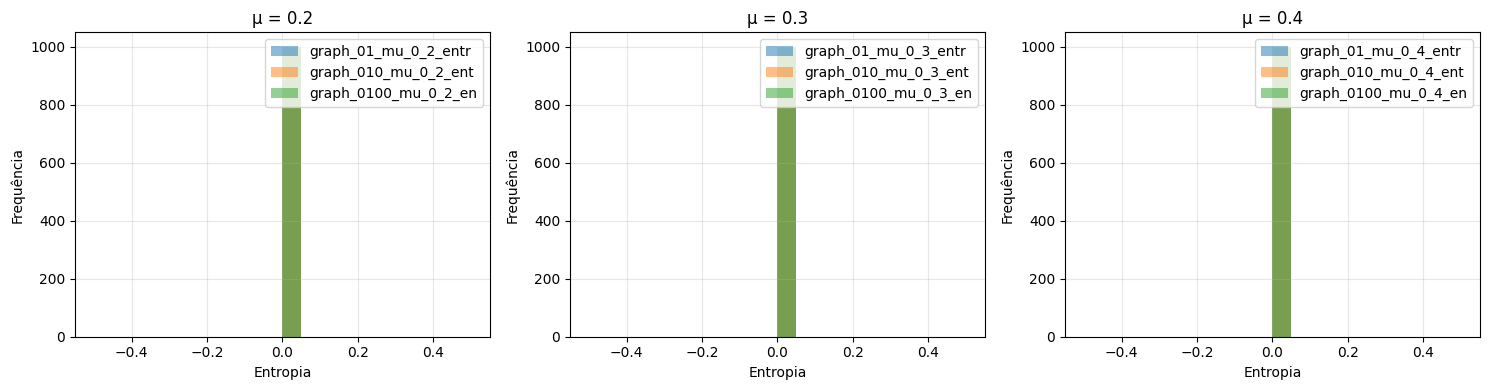

In [4]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================
# CONFIGURAÇÃO
# ============================================

BASE_PATH = Path("LFR_Graph_Data/Community_Data/Infomap/Node_Entropies")

# ============================================
# FUNÇÃO PARA ANALISAR ENTROPIAS DO INFOMAP
# ============================================

def analyze_infomap_entropies(base_path):
    """
    Analisa todas as entropias do Infomap para demonstrar comportamento determinístico.
    """
    
    print("=" * 70)
    print("📊 ANÁLISE DE ENTROPIAS - INFOMAP")
    print("=" * 70)
    
    # Lista todos os arquivos de entropia
    entropy_files = list(base_path.glob("*.csv"))
    
    if not entropy_files:
        print("❌ Nenhum arquivo de entropia encontrado.")
        return
    
    print(f"📁 Encontrados {len(entropy_files)} arquivos de entropia")
    
    # Análise detalhada
    results = []
    all_zero_count = 0
    
    for file in sorted(entropy_files):
        try:
            df = pd.read_csv(file, index_col=0)
            
            # Verifica coluna de entropia
            entropy_col = [col for col in df.columns if 'entropy' in col.lower()]
            if not entropy_col:
                entropy_col = df.columns[0]
            else:
                entropy_col = entropy_col[0]
            
            entropies = df[entropy_col].values
            
            # Estatísticas
            n_nodes = len(entropies)
            n_zero = np.sum(entropies == 0)
            n_nonzero = n_nodes - n_zero
            all_zero = n_zero == n_nodes
            max_entropy = np.max(entropies) if n_nonzero > 0 else 0
            
            results.append({
                'file': file.name,
                'n_nodes': n_nodes,
                'n_zero': n_zero,
                'n_nonzero': n_nonzero,
                'all_zero': all_zero,
                'max_entropy': max_entropy,
                'mean_entropy': np.mean(entropies)
            })
            
            if all_zero:
                all_zero_count += 1
                
        except Exception as e:
            print(f"  ❌ Erro em {file.name}: {e}")
    
    # ============================================
    # EXIBIR RESULTADOS AGREGADOS
    # ============================================
    
    print("\n" + "=" * 70)
    print("📊 RESULTADOS AGREGADOS")
    print("=" * 70)
    
    df_results = pd.DataFrame(results)
    
    print(f"\n📈 Estatísticas gerais:")
    print(f"  Total de arquivos: {len(df_results)}")
    print(f"  Arquivos com TODOS os nós com entropia zero: {all_zero_count}/{len(df_results)}")
    print(f"  Proporção: {all_zero_count/len(df_results)*100:.1f}%")
    
    if not df_results.empty:
        print(f"\n📊 Estatísticas de entropia:")
        print(f"  Média de entropia (global): {df_results['mean_entropy'].mean():.6f}")
        print(f"  Máximo de entropia (global): {df_results['max_entropy'].max():.6f}")
        print(f"  Total de nós analisados: {df_results['n_nodes'].sum():,}")
        print(f"  Nós com entropia zero: {df_results['n_zero'].sum():,}")
        print(f"  Nós com entropia > 0: {df_results['n_nonzero'].sum():,}")
    
    # ============================================
    # ANALISAR POR μ
    # ============================================
    
    print("\n" + "=" * 70)
    print("📊 ANÁLISE POR μ")
    print("=" * 70)
    
    for mu in ['0_2', '0_3', '0_4']:
        mu_files = [f for f in results if f'mu_{mu}' in f['file']]
        
        if mu_files:
            df_mu = pd.DataFrame(mu_files)
            all_zero_mu = df_mu['all_zero'].sum()
            
            print(f"\n📌 μ = {mu.replace('_', '.')}")
            print(f"  Arquivos: {len(df_mu)}")
            print(f"  Total de nós: {df_mu['n_nodes'].sum():,}")
            print(f"  Nós com entropia zero: {df_mu['n_zero'].sum():,}")
            print(f"  Nós com entropia > 0: {df_mu['n_nonzero'].sum():,}")
            print(f"  Arquivos com entropia zero: {all_zero_mu}/{len(df_mu)} ({all_zero_mu/len(df_mu)*100:.1f}%)")
            print(f"  Média de entropia: {df_mu['mean_entropy'].mean():.6f}")
            print(f"  Máximo de entropia: {df_mu['max_entropy'].max():.6f}")
    
    # ============================================
    # VERIFICAR CASOS COM ENTROPIA NÃO-ZERO
    # ============================================
    
    non_zero_cases = [r for r in results if not r['all_zero']]
    
    if non_zero_cases:
        print("\n" + "=" * 70)
        print("⚠️ CASOS COM ENTROPIA NÃO-ZERO (POSSÍVEL VARIABILIDADE)")
        print("=" * 70)
        for r in non_zero_cases[:10]:
            print(f"  {r['file']}: {r['n_nonzero']} nós com entropia > 0 (max={r['max_entropy']:.6f})")
    else:
        print("\n" + "=" * 70)
        print("✅ CONFIRMADO: TODOS OS ARQUIVOS TÊM ENTROPIA ZERO")
        print("=" * 70)
        print("   O Infomap apresentou comportamento DETERMINÍSTICO")
        print("   para TODAS as configurações testadas.")
        print("   Partições idênticas em todas as 1000 execuções.")
    
    # ============================================
    # VISUALIZAÇÃO
    # ============================================
    
    # Plot da distribuição de entropias (primeiros 5 arquivos)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for idx, mu in enumerate(['0_2', '0_3', '0_4']):
        ax = axes[idx]
        
        mu_files = [f for f in entropy_files if f'mu_{mu}' in f.name]
        
        if mu_files:
            # Pega os 3 primeiros arquivos
            for file in mu_files[:3]:
                df = pd.read_csv(file, index_col=0)
                entropy_col = [col for col in df.columns if 'entropy' in col.lower()]
                if not entropy_col:
                    entropy_col = df.columns[0]
                else:
                    entropy_col = entropy_col[0]
                entropies = df[entropy_col].values
                
                ax.hist(entropies, bins=20, alpha=0.5, label=file.name[:20])
            
            ax.set_title(f"μ = {mu.replace('_', '.')}")
            ax.set_xlabel("Entropia")
            ax.set_ylabel("Frequência")
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("infomap_entropy_distribution.png", dpi=150)
    plt.show()
    
    return df_results

# ============================================
# EXECUÇÃO
# ============================================

if __name__ == "__main__":
    df = analyze_infomap_entropies(BASE_PATH)

In [5]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================
# CONFIGURAÇÃO
# ============================================

BASE_PATH = Path("LFR_Graph_Data/Community_Data/Infomap/Node_Entropies")

# ============================================
# FUNÇÃO PARA GERAR TABELA DE ENTROPIAS
# ============================================

def generate_infomap_entropy_table(base_path):
    """
    Gera uma tabela com estatísticas de entropia do Infomap para demonstrar
    comportamento determinístico.
    """
    
    print("=" * 70)
    print("📊 GERANDO TABELA DE ENTROPIAS - INFOMAP")
    print("=" * 70)
    
    # Lista todos os arquivos de entropia
    entropy_files = list(base_path.glob("*.csv"))
    
    if not entropy_files:
        print("❌ Nenhum arquivo de entropia encontrado.")
        return None
    
    print(f"📁 Encontrados {len(entropy_files)} arquivos de entropia")
    
    # Agrupa por μ
    results_by_mu = {}
    
    for mu in ['0_2', '0_3', '0_4']:
        mu_files = [f for f in entropy_files if f'mu_{mu}' in f.name]
        
        if not mu_files:
            continue
        
        total_nodes = 0
        total_zero = 0
        total_nonzero = 0
        max_entropy = 0.0
        mean_entropy = 0.0
        
        for file in mu_files:
            try:
                df = pd.read_csv(file, index_col=0)
                
                # Identifica coluna de entropia
                entropy_col = [col for col in df.columns if 'entropy' in col.lower()]
                if not entropy_col:
                    entropy_col = df.columns[0]
                else:
                    entropy_col = entropy_col[0]
                
                entropies = df[entropy_col].values
                
                n_nodes = len(entropies)
                n_zero = np.sum(entropies == 0)
                n_nonzero = n_nodes - n_zero
                
                total_nodes += n_nodes
                total_zero += n_zero
                total_nonzero += n_nonzero
                
                if n_nonzero > 0:
                    max_entropy = max(max_entropy, np.max(entropies))
                
            except Exception as e:
                print(f"  ❌ Erro em {file.name}: {e}")
        
        results_by_mu[mu] = {
            'n_files': len(mu_files),
            'total_nodes': total_nodes,
            'total_zero': total_zero,
            'total_nonzero': total_nonzero,
            'zero_percent': (total_zero / total_nodes) * 100 if total_nodes > 0 else 0,
            'max_entropy': max_entropy,
            'mean_entropy': mean_entropy
        }
    
    return results_by_mu

# ============================================
# FUNÇÃO PARA GERAR TABELA LaTeX
# ============================================

def generate_latex_table(results_by_mu):
    """
    Gera tabela LaTeX formatada para o TCC.
    """
    latex_lines = []
    
    latex_lines.append("\\begin{table}[H]")
    latex_lines.append("\\centering")
    latex_lines.append("\\caption{Estatísticas de entropia para o algoritmo Infomap}")
    latex_lines.append("\\label{tab:infomap_entropy}")
    latex_lines.append("\\begin{tabular}{lcccccc}")
    latex_lines.append("\\hline")
    latex_lines.append("\\textbf{$\\mu$} & \\textbf{Nº Grafos} & \\textbf{Total Nós} & \\textbf{Nós com E=0} & \\textbf{Nós com E>0} & \\textbf{\\% Zero} & \\textbf{Max Entropia} \\\\")
    latex_lines.append("\\hline")
    
    for mu in ['0_2', '0_3', '0_4']:
        if mu in results_by_mu:
            r = results_by_mu[mu]
            mu_display = mu.replace('_', '.')
            latex_lines.append(
                f"{mu_display} & {r['n_files']} & {r['total_nodes']:,} & "
                f"{r['total_zero']:,} & {r['total_nonzero']:,} & "
                f"{r['zero_percent']:.1f}\\% & {r['max_entropy']:.6f} \\\\"
            )
    
    latex_lines.append("\\hline")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")
    
    return "\n".join(latex_lines)

# ============================================
# FUNÇÃO PARA GERAR TABELA RESUMO (ESTILO ABNT)
# ============================================

def generate_abnt_table(results_by_mu):
    """
    Gera tabela no estilo ABNT para o TCC.
    """
    latex_lines = []
    
    latex_lines.append("\\begin{table}[H]")
    latex_lines.append("\\centering")
    latex_lines.append("\\caption{Comportamento determinístico do Infomap: entropia zero para todos os nós}")
    latex_lines.append("\\label{tab:infomap_deterministic}")
    latex_lines.append("\\begin{tabular}{lcccc}")
    latex_lines.append("\\hline")
    latex_lines.append("\\textbf{Parâmetro $\\mu$} & \\textbf{Nº de Grafos} & \\textbf{Total de Nós} & \\textbf{Nós com Entropia Zero} & \\textbf{Proporção (\\%)} \\\\")
    latex_lines.append("\\hline")
    
    for mu in ['0_2', '0_3', '0_4']:
        if mu in results_by_mu:
            r = results_by_mu[mu]
            mu_display = mu.replace('_', '.')
            latex_lines.append(
                f"{mu_display} & {r['n_files']} & {r['total_nodes']:,} & "
                f"{r['total_zero']:,} & {r['zero_percent']:.1f}\\% \\\\"
            )
    
    latex_lines.append("\\hline")
    latex_lines.append("\\multicolumn{5}{l}{\\footnotesize Fonte: Elaborado pelo autor.} \\\\")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")
    
    return "\n".join(latex_lines)

# ============================================
# FUNÇÃO PARA GERAR TABELA CSV
# ============================================

def generate_csv_table(results_by_mu, output_file="infomap_entropy_table.csv"):
    """
    Gera tabela em formato CSV.
    """
    rows = []
    
    for mu in ['0_2', '0_3', '0_4']:
        if mu in results_by_mu:
            r = results_by_mu[mu]
            rows.append({
                'mu': mu.replace('_', '.'),
                'n_graphs': r['n_files'],
                'total_nodes': r['total_nodes'],
                'nodes_zero': r['total_zero'],
                'nodes_nonzero': r['total_nonzero'],
                'zero_percent': r['zero_percent'],
                'max_entropy': r['max_entropy']
            })
    
    df = pd.DataFrame(rows)
    df.to_csv(output_file, index=False)
    print(f"\n💾 CSV salvo em: {output_file}")
    
    return df

# ============================================
# EXECUÇÃO PRINCIPAL
# ============================================

if __name__ == "__main__":
    
    # Gera tabela de entropias
    results = generate_infomap_entropy_table(BASE_PATH)
    
    if results:
        # Exibe tabela
        print("\n" + "=" * 70)
        print("📊 TABELA DE ENTROPIAS - INFOMAP")
        print("=" * 70)
        
        print("\nμ       Grafos  Total Nós  E=0      E>0      % Zero   Max Entropia")
        print("-" * 70)
        for mu in ['0_2', '0_3', '0_4']:
            if mu in results:
                r = results[mu]
                mu_display = mu.replace('_', '.')
                print(f"{mu_display}     {r['n_files']:>6}  {r['total_nodes']:>9,}  "
                      f"{r['total_zero']:>6,}  {r['total_nonzero']:>6}  "
                      f"{r['zero_percent']:>6.1f}%  {r['max_entropy']:>12.6f}")
        
        # Gera tabela LaTeX
        latex_table = generate_latex_table(results)
        with open("infomap_entropy_table.tex", "w") as f:
            f.write(latex_table)
        print("\n📄 Tabela LaTeX salva em: infomap_entropy_table.tex")
        
        # Gera tabela ABNT
        abnt_table = generate_abnt_table(results)
        with open("infomap_entropy_table_abnt.tex", "w") as f:
            f.write(abnt_table)
        print("📄 Tabela ABNT salva em: infomap_entropy_table_abnt.tex")
        
        # Gera CSV
        generate_csv_table(results)

📊 GERANDO TABELA DE ENTROPIAS - INFOMAP
📁 Encontrados 360 arquivos de entropia

📊 TABELA DE ENTROPIAS - INFOMAP

μ       Grafos  Total Nós  E=0      E>0      % Zero   Max Entropia
----------------------------------------------------------------------
0.2        120    120,000  120,000       0   100.0%      0.000000
0.3        120    120,000  120,000       0   100.0%      0.000000
0.4        120    120,000  120,000       0   100.0%      0.000000

📄 Tabela LaTeX salva em: infomap_entropy_table.tex
📄 Tabela ABNT salva em: infomap_entropy_table_abnt.tex

💾 CSV salvo em: infomap_entropy_table.csv


In [13]:
algorithm = "lpa"

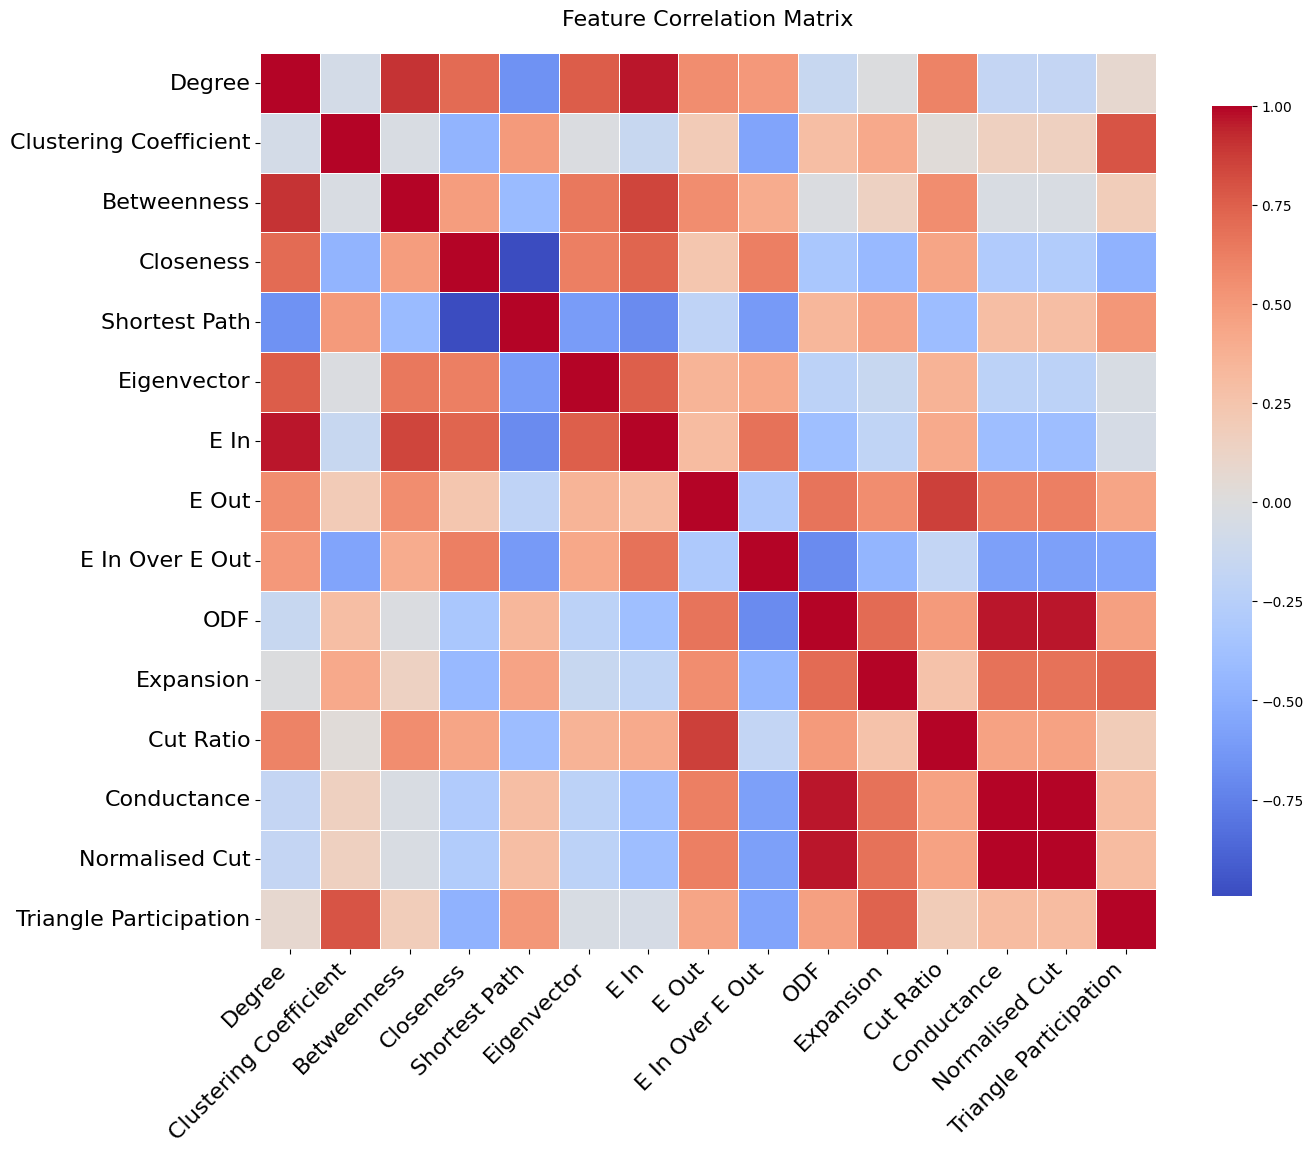

<Figure size 640x480 with 0 Axes>

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load all feature CSVs
feats_folder = f'LFR_Graph_Data/Community_Data/{algorithm}/Node_Features/'
all_dfs = []

for csv_file in os.listdir(feats_folder):
    if csv_file.endswith('_features.csv'):
        df = pd.read_csv(os.path.join(feats_folder, csv_file))
        all_dfs.append(df)

# Combine
features_df = pd.concat(all_dfs, ignore_index=True)

# Calculate correlation
corr_matrix = features_df.select_dtypes(include=[np.number]).corr()

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, 
           linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right',fontsize=16)
plt.yticks(rotation=0,fontsize=16)
plt.tight_layout()
plt.show()

# Save
output_dir = 'correlation_results'
os.makedirs(output_dir, exist_ok=True)
corr_matrix.to_csv(os.path.join(output_dir, 'correlation_matrix.csv'))
plt.savefig(os.path.join(output_dir, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')